# Deep Learning Overview

            ## 1. Learning objectives

            - Describe neurons, layers, activations, loss, and optimization
- Trace input, hidden, and output shapes
- Build the same tiny network with NumPy and PyTorch

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Learn useful intermediate representations and a prediction function together.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            Each layer rewrites the data into a form the next layer can use; loss tells the network how the final answer should change.

## 6. Mathematical foundation

            $$\mathbf{h}=\phi(\mathbf{X}\mathbf{W}+\mathbf{b}).$$

            **Every symbol:**

            - $\mathbf{X}$ is a batch of inputs.
- $\mathbf{W}$ is a learned weight matrix.
- $\mathbf{b}$ is a learned bias vector.
- $\phi$ is an activation function.
- $\mathbf{h}$ is the resulting representation.

            **Why the equation is needed:** Without the activation, stacked linear layers collapse to one linear transformation; the activation enables nonlinear patterns.

            **Small numerical example:** For x=[1,2], w=[.5,-.25], and b=.1, z=1(.5)+2(-.25)+.1=.1; ReLU(z)=.1.

            **Connection to Python:** torch.relu(X @ W + b) implements the equation while autograd records the operations.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def sigmoid(values):
    return 1 / (1 + np.exp(-values))

X_np = np.array([[1.0, 2.0], [-1.0, 1.0]])
W_np = np.array([[.4, -.2], [.1, .3]])
b_np = np.array([.0, .1])
hidden_np = np.maximum(X_np @ W_np + b_np, 0)
output_np = sigmoid(hidden_np @ np.array([.7, -.5]))
print("Input:", X_np.shape, "hidden:", hidden_np.shape, "output:", output_np.shape)
print("NumPy outputs:", output_np.round(3))

Input: (2, 2) hidden: (2, 2) output: (2,)
NumPy outputs: [0.542 0.426]


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Input shape: (2, 2)
Intermediate shape: (2, 4)
Output shape: (2, 1)
Trainable parameters: 17


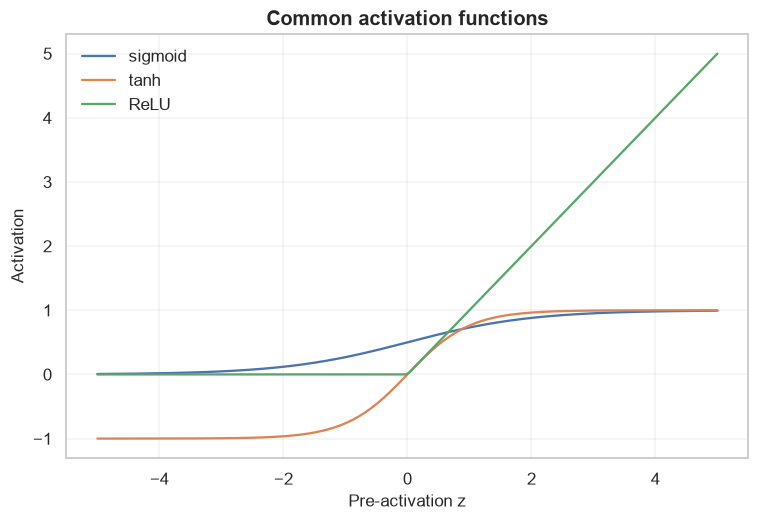

In [3]:
model = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())
X = torch.tensor([[1., 2.], [-1., 1.]])
with torch.no_grad():
    hidden = model[1](model[0](X))
    predictions = model(X)
print("Input shape:", tuple(X.shape))
print("Intermediate shape:", tuple(hidden.shape))
print("Output shape:", tuple(predictions.shape))
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

activations = {
    "sigmoid": torch.sigmoid(torch.linspace(-5, 5, 200)),
    "tanh": torch.tanh(torch.linspace(-5, 5, 200)),
    "ReLU": torch.relu(torch.linspace(-5, 5, 200)),
}
figure, axis = plt.subplots()
grid = np.linspace(-5, 5, 200)
for name, values in activations.items():
    axis.plot(grid, values.numpy(), label=name)
axis.set(title="Common activation functions", xlabel="Pre-activation z", ylabel="Activation")
axis.legend()
plt.show()

**How to interpret the result:** Sigmoid and tanh saturate at large magnitudes; ReLU keeps a constant positive-side slope and is common in hidden layers.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Depth increases composition but also changes optimization, memory, and overfitting risk; the plotted capacity is illustrative rather than a measured accuracy.

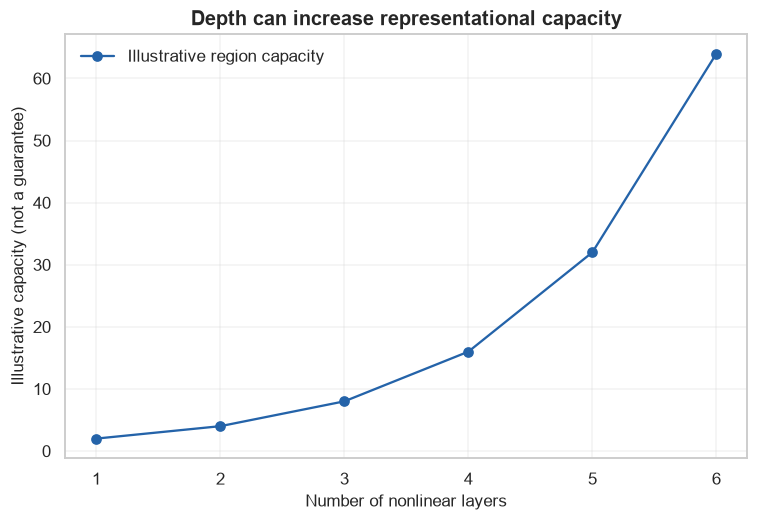

In [4]:
depths = np.arange(1, 7)
linear_regions_proxy = 2 ** depths
figure, axis = plt.subplots()
axis.plot(depths, linear_regions_proxy, marker="o", color=COURSE_COLORS["blue"], label="Illustrative region capacity")
axis.set(title="Depth can increase representational capacity", xlabel="Number of nonlinear layers", ylabel="Illustrative capacity (not a guarantee)")
axis.legend()
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)